In [ ]:
!pip install pandas numpy scikit-learn missingno openpyxl

In [2]:
#Load Data
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
import missingno as msno
import warnings
warnings.filterwarnings('ignore')


file_path = "BD_MedWaste_2000_2023.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], "...")

Shape: (192, 44)
Columns: ['Year', 'Division', 'Number_of_Hospitals', 'Number_of_Beds', 'Crude_Birth_Rate', 'GDP_per_Capita_USD', 'Dengue_Cases', 'Beds_per_1000_Pop', 'Hospitals_per_100k_Pop', 'Avg_Beds_per_Hospital'] ...


In [ ]:
# Audit missing values
# Missing counts and percentage
missing_summary = df.isna().sum().to_frame('Missing_Count')
missing_summary['Missing_%'] = 100 * missing_summary['Missing_Count'] / len(df)
display(missing_summary.sort_values('Missing_%', ascending=False))
# Visual missingness map (for visual inspection)
msno.matrix(df)
# Identify zero-coded missing values in epidemiological columns (such as no dengue reporting years)
zero_mask_cols = ['Dengue_Cases', 'Infectious_Waste_kg_day']
for col in zero_mask_cols:
    zero_count = (df[col] == 0).sum()
    if zero_count > 0:
        print(f" {col}: {zero_count} rows with zero — check if true zero or missing data.")

In [4]:
#Separate variable groups
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Time-series numeric columns that should respect temporal order
time_series_cols = [
    'GDP_per_Capita_USD', 'Crude_Birth_Rate', 'Number_of_Hospitals',
    'Number_of_Beds', 'Dengue_Cases'
]

In [5]:

#Sort data properly

df = df.sort_values(['Division', 'Year'])
# Step 1: Time-series fill (FIXED: use transform, not apply)
df[time_series_cols] = df.groupby('Division')[time_series_cols].transform(
    lambda x: x.ffill().bfill()
)
# Step 2: KNN Imputation
knn_numeric_cols = [col for col in numeric_cols if col not in ['Year']]

knn_imputer = KNNImputer(n_neighbors=5)

df[knn_numeric_cols] = pd.DataFrame(
    knn_imputer.fit_transform(df[knn_numeric_cols]),
    columns=knn_numeric_cols,
    index=df.index
)

# Step 3: Iterative Imputer (MICE) FIXED
iter_impute_cols = [
    'General_Waste_kg_day', 'Infectious_Waste_kg_day', 'Sharps_Waste_kg_day',
    'Pharmaceutical_Waste_kg_day', 'Chemical_Waste_kg_day',
    'Total_Medical_Waste_kg_day', 'Total_Hazardous_Waste_kg_day'
]

mice = IterativeImputer(random_state=42)

df[iter_impute_cols] = pd.DataFrame(
    mice.fit_transform(df[iter_impute_cols]),
    columns=iter_impute_cols,
    index=df.index
)

In [7]:
#Encode and impute categorical nulls
categorical_cols_with_nan = [col for col in categorical_cols if df[col].isna().any()]
for col in categorical_cols_with_nan:
    df[col] = df[col].fillna('Unknown')
# Encode categorical features (for model-ready ML version)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoded_df = df.copy()
encoded_df[categorical_cols] = encoder.fit_transform(encoded_df[categorical_cols])
print("Categorical encoding complete.")

Categorical encoding complete.


Remaining missing after imputation:
0
 Saved: cleaned and encoded files ready for modeling.


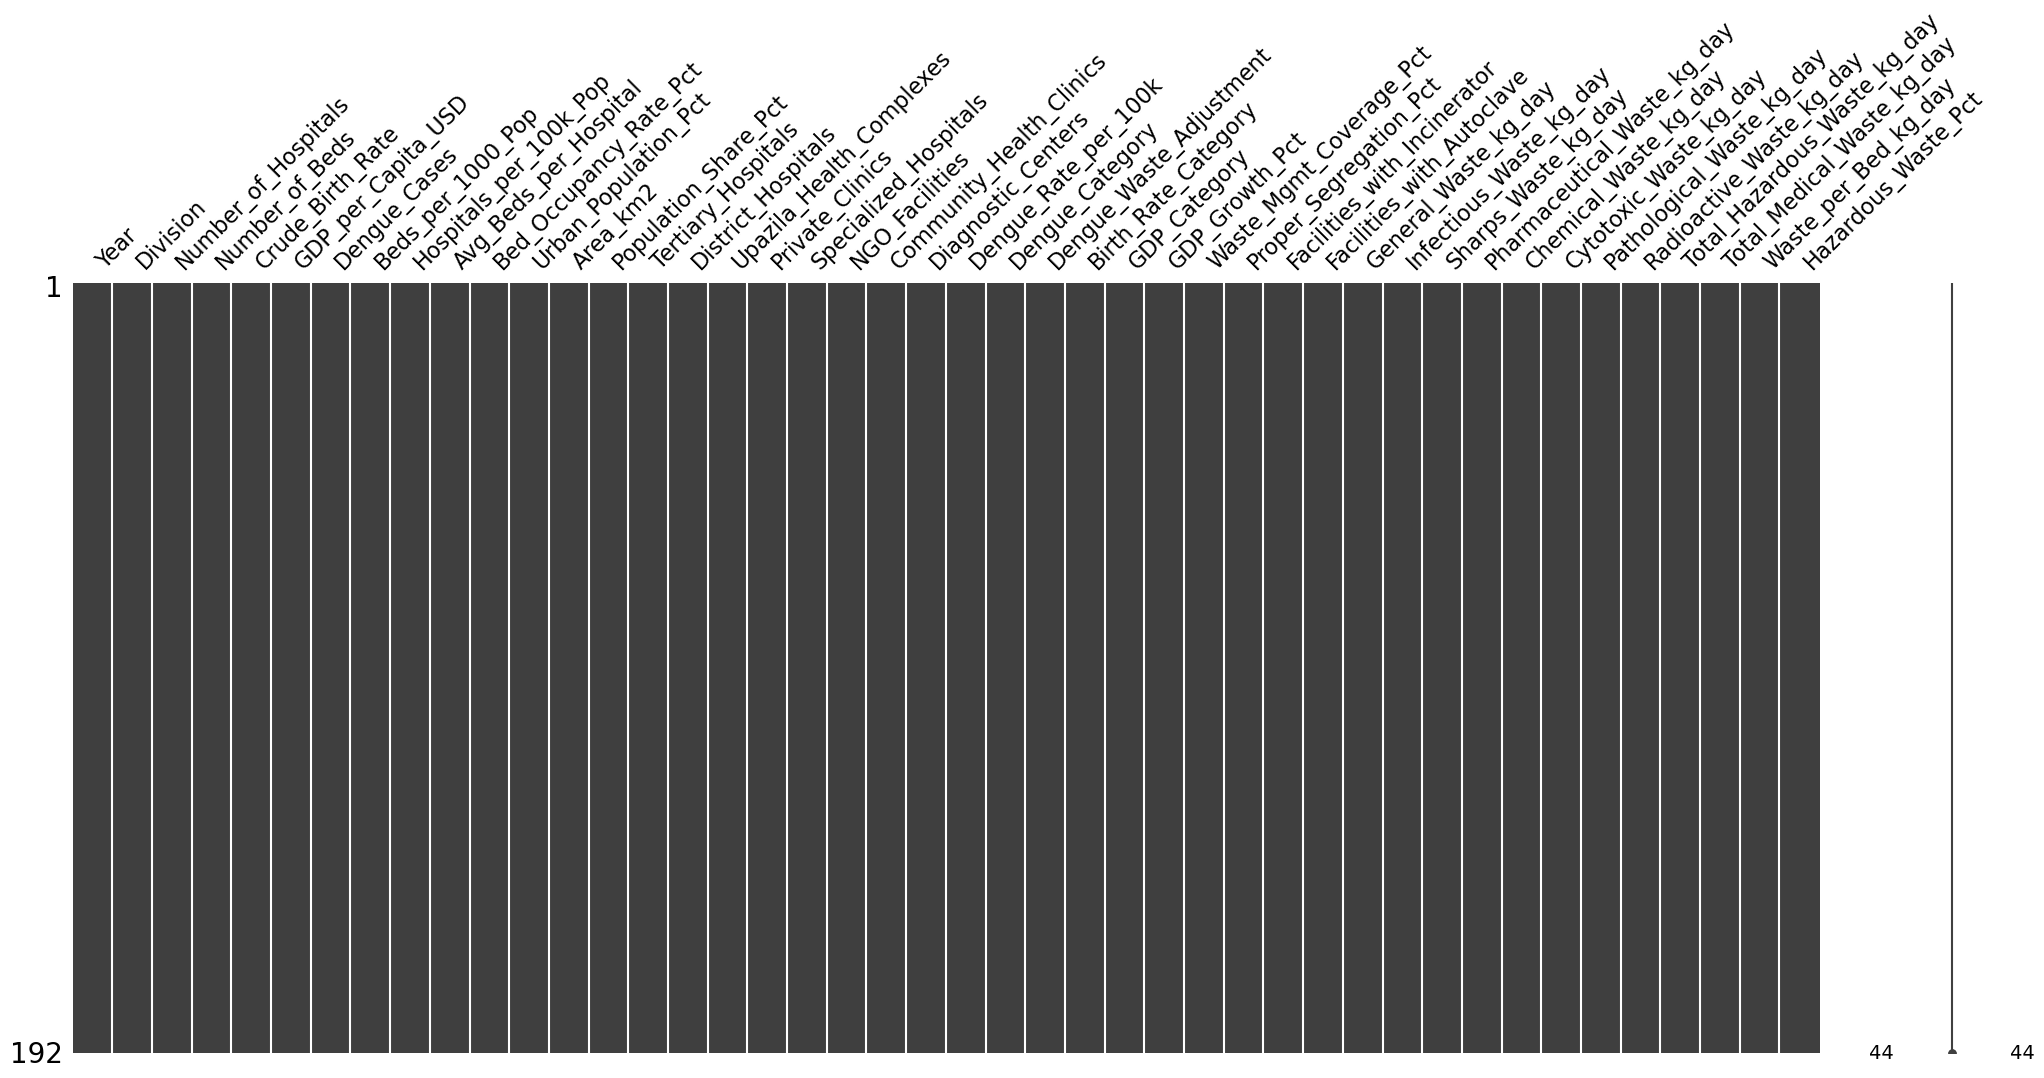

In [8]:
#Final check
print("Remaining missing after imputation:")
print(encoded_df.isna().sum().sum())
msno.matrix(encoded_df)
#Export cleaned datasets
encoded_df.to_csv("BD_MedWaste_2000_2023_Cleaned_Encoded.csv", index=False)
df.to_csv("BD_MedWaste_2000_2023_Cleaned.csv", index=False)
print(" Saved: cleaned and encoded files ready for modeling.")